In [91]:
from IPython.display import Image, display

# BASIC OF PYCAIRO

## What is PyCairo

- ⁡⁣⁣⁢PyCairo⁡ is a Python library for 2D graphics.
- It provides Python bindings for the Cairo graphics library, which allows you to create vector-based graphics that can be rendered to various output formats, such as PNG images, PDF files, SVG files, or directly to a window or surface.
- We can install PyCairo by running the following pip command in terminal:

In [92]:
pip install pycairo

Note: you may need to restart the kernel to use updated packages.


## Simple Image with PyCairo

Every image is divided into two parts:
- Surface (canvas)
- Drawing

To use PyCairo we create a ⁡⁣⁣⁢𝘀𝘂𝗿𝗳𝗮𝗰𝗲⁡ to draw on.
- A surface is an object where we create our image.
- When creating an image we need to specify:
  - type of output: PNG, PDF, SVG
  - image format: FORMAT_RGB24
  - image size: (width, length)

The surface has inverted axes that can be as shown below
<pre>
--------------------------->x-axis
|
|
|
|
|
|
|
↓↓
y-axis
</pre>

After creating a surface we need to create a ⁡⁣⁣⁢𝗰𝗼𝗻𝘁𝗲𝘅𝘁⁡.
- A context is a tool we use to draw on our surface.

Lastly, we use our context tool to paint/fill the surface with a color using the `.paint()` function.

Import the PyCairo library using the line below

In [93]:
import cairo

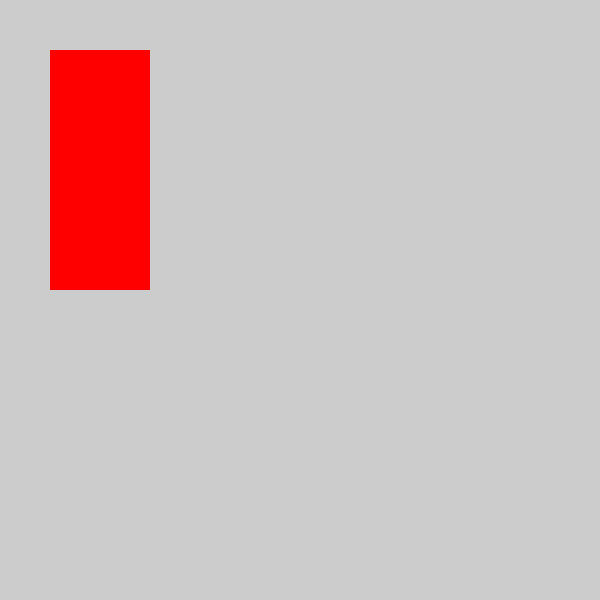

In [94]:
# 1. 𝕊𝕖𝕥𝕥𝕚𝕟𝕘 𝕦𝕡 𝕒 𝕤𝕦𝕣𝕗𝕒𝕔𝕖
surface = cairo.ImageSurface(cairo.FORMAT_RGB24, 600, 600) 
# PARAMETERS: output type (ImageSurface == png)
# ,format, width, length

# 2. 𝕊𝕖𝕥𝕦𝕡 𝕒 𝕓𝕣𝕦𝕤𝕙 𝕒𝕜𝕒 𝕔𝕠𝕟𝕥𝕖𝕩𝕥
context = cairo.Context(surface)
# takes the surface/canvas as argument
context.set_source_rgb(0.8, 0.8, 0.8)
# pick color of surface with rgb values
context.paint()
# set paint color on surface

# 3. 𝔻𝕣𝕒𝕨 𝕒𝕟 𝕚𝕞𝕒𝕘𝕖
context.rectangle(50,50,100,240)
# give coordinates and dimensions
context.set_source_rgb(1,0,0)
# pick color of rectangle with rgb values
context.fill()
# set paint to fill rectangle

surface.write_to_png('Images/1.basics.png')
display(Image(filename='Images/1.basics.png'))

## Using Fill and Stroke

Fill is used to fill an image/shape with a specific color while Stroke is used to outline a shape/image with a specific color.
- Fill uses the `.fill()` function
- Stroke uses the `.stroke()` function

To incorporte both fill and stroke in a shape/image we need to use the `fill_preserve()` function to fill the image with specific color then use the `.stroke()` to outline it with the specific color. We can also set the line width using the `.set_line_width()` function.
- Fill uses the `.fill_preserve()` function
- Stroke uses the `.stroke()` function

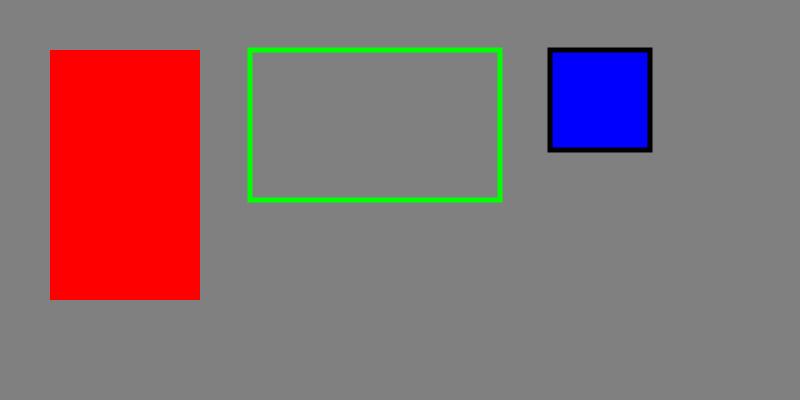

In [95]:
surface = cairo.ImageSurface(cairo.FORMAT_RGB24, 800, 400)
ctx = cairo.Context(surface)
ctx.set_source_rgb(0.5, 0.5, 0.5)
ctx.paint()

# Red rectangle - fill only
ctx.rectangle(50, 50, 150, 250)
ctx.set_source_rgb(1, 0, 0)
ctx.fill()

# Green rectangle - stroke only
ctx.rectangle(250, 50, 250, 150)
ctx.set_source_rgb(0,1,0)
ctx.set_line_width(5) # need to set a line width if using stoke
ctx.stroke()

# Blue square - fill and stroke
ctx. rectangle(550, 50, 100, 100)
ctx.set_source_rgb(0,0,1)
ctx.fill_preserve() # set to fill preserve to have fill then describe the stroke 
ctx.set_source_rgb(0,0,0) # set color for stroke separately
ctx.set_line_width(5)
ctx.stroke()

surface.write_to_png('Images/2.fill_stroke.png')
display(Image(filename='Images/2.fill_stroke.png'))

## Open and Closed Shapes

Pycairo uses the idea of a current point when drawing shapes. This makes it easy to create common shapes, such as polygons, which are formed through the end-to-end joining of lines or curves.

Initially the path is empty and the current point is undefined so we have to set it using the `.move_to()` function. The next point is designated using the `.line_to()` function.

After points on a line have been set, we set the color and width and use `.stroke()` to draw it.

In [96]:
# Clear the surface
ctx.set_source_rgb(1, 1, 1) 
ctx.paint()

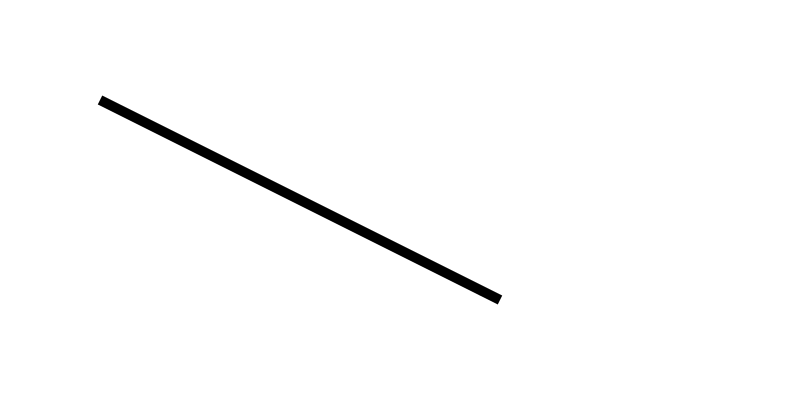

In [97]:
# Drawing lines
ctx.move_to(100, 100) # setting start coordinate
ctx. line_to(500, 300) # setting other coordinates
ctx.set_source_rgb(0,0,0)
ctx.set_line_width(10)
ctx.stroke() # a it is a line use stroke

surface.write_to_png('Images/3.draw_line.png')
display(Image(filename='Images/3.draw_line.png'))

The above format can only be used to form an open shape which is mainly for decorative dividers and symbols as shown below. 

In [98]:
# Clear the surface
ctx.set_source_rgb(1, 1, 1) 
ctx.paint()

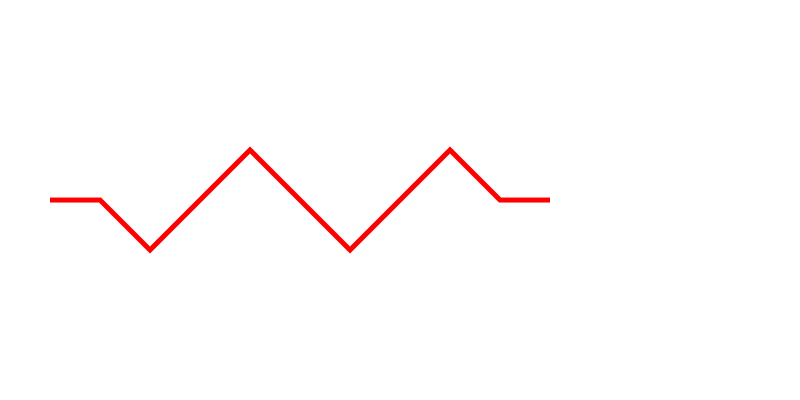

In [99]:
# Open polygon - decorative dividers, symbols, arrows
ctx.move_to(50, 200)
ctx.line_to(100, 200)
ctx.line_to(150, 250)
ctx.line_to(250, 150)
ctx.line_to(350, 250)
ctx.line_to(450, 150)
ctx.line_to(500, 200)
ctx.line_to(550, 200)
ctx.set_source_rgb(1,0,0)
ctx.set_line_width(5)
ctx.stroke()

surface.write_to_png('Images/4.open_shape.png')
display(Image(filename='Images/4.open_shape.png'))

In order to create closed shapes, we have to add the `.close_path()` function before we stroke the path. This will create a line from our current point to the starting point of the line.

We can this create our own complex shapes apart from PyCairo's predefined ones like rectangle {`.rectangle(x,y,w,l)`}

In [100]:
# Clear the surface
ctx.set_source_rgb(1, 1, 1) 
ctx.paint()

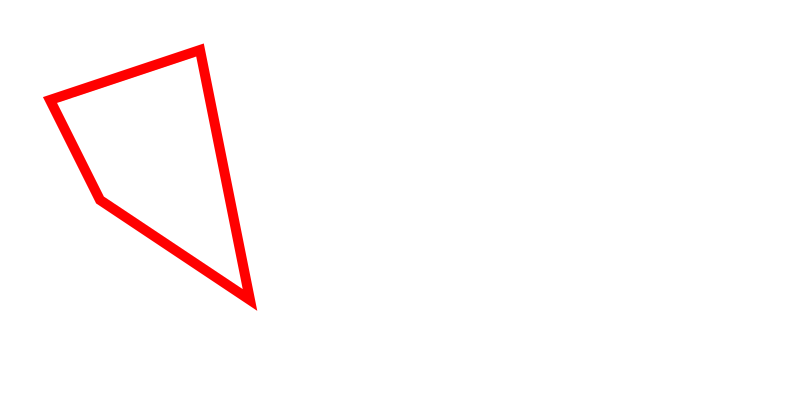

In [101]:
# Closed polygon
ctx.move_to(50, 100)  # A
ctx.line_to(200,50)   # B
ctx.line_to(250, 300) # C
ctx.line_to(100,200)  # D
ctx.close_path() # adds a line btn last point and first point in path
ctx.set_source_rgb(1,0,0)
ctx.set_line_width(10)
ctx.stroke()

surface.write_to_png('Images/5.closed_shape.png')
display(Image(filename='Images/5.closed_shape.png'))

## Circles and Curves

In PyCairo, we do not have a function to draw a circle, instead we use the concept if arcs.
- An arc is part of the circumference of a circle.
- The arc function is called as shown below
- `ctx.arc(cx,cy,r,a1,a2)`

- 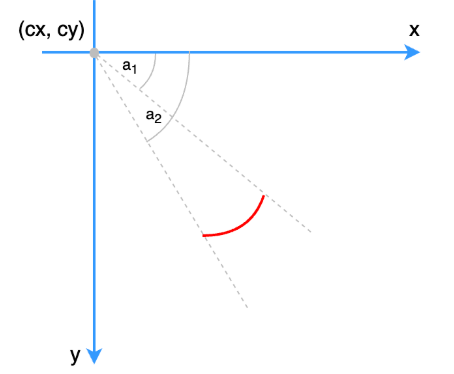

To use arcs we need to install the math library as we need PI(π). 𝗡𝗼𝘁𝗲: by default arc function calculates in radians thus if we want to use degrees instead we have to use the `.radians()` function.

Below is a map for radians to degrees:
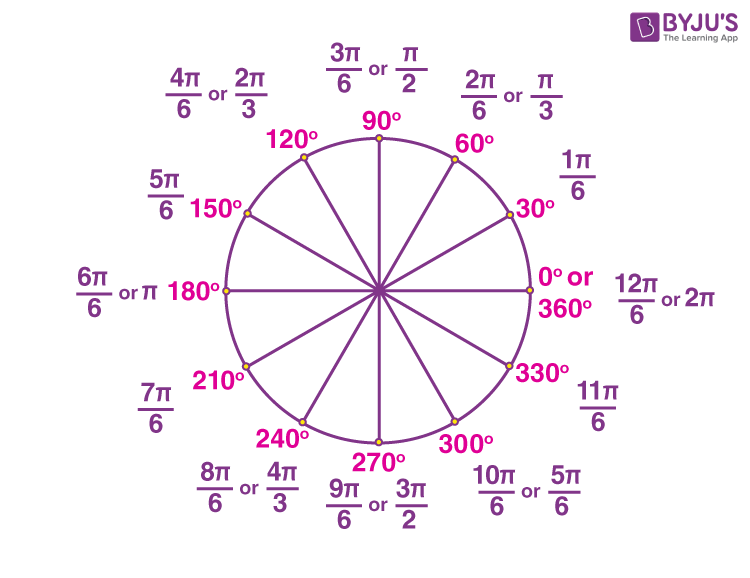

In [102]:
pip install python-math

Note: you may need to restart the kernel to use updated packages.


In [103]:
import math

Drawing a simple arc

In [104]:
# Clear surface
ctx.set_source_rgb(1, 1, 1)
ctx.paint()

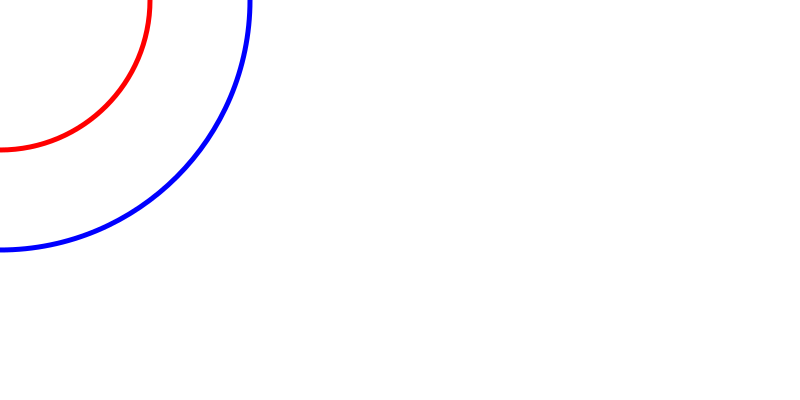

In [105]:
# Draw an arc

# Using default radians 
ctx.arc(0, 0, 150, 0, math.pi/2)
# We use radians where 2*math.pi is a full circle
ctx.set_source_rgb(1,0,0)
ctx.set_line_width(5)
ctx.stroke()

# Using .radians() for degrees
ctx.arc(0, 0, 250, 0, math.radians(90))
ctx.set_source_rgb(0,0,1)
ctx.set_line_width(5)
ctx.stroke()

surface.write_to_png('Images/6.simple_arc.png')
display(Image(filename='Images/6.simple_arc.png'))

Drawing circles

In [106]:
# Clear surface
ctx.set_source_rgb(1, 1, 1)
ctx.paint()

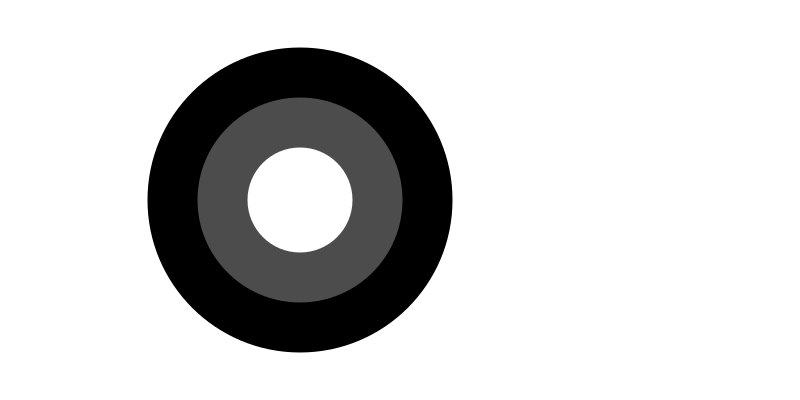

In [107]:
# Draw an circles

# Using default radians 
ctx.arc(300,200,150,0,2*math.pi)
ctx.set_source_rgb(0,0,0)
ctx.fill_preserve()
ctx.set_source_rgb(0,0,0)
ctx.set_line_width(5)
ctx.stroke()

ctx.arc(300,200,100,0,2*math.pi)
ctx.set_source_rgb(0.3,0.3,0.3)
ctx.fill_preserve()
ctx.set_source_rgb(0.3,0.3,0.3)
ctx.set_line_width(5)
ctx.stroke()

# Using .radians() for degrees
ctx.arc(300,200,50,0,math.radians(360))
ctx.set_source_rgb(1,1,1)
ctx.fill_preserve()
ctx.set_source_rgb(1,1,1)
ctx.set_line_width(5)
ctx.stroke()

surface.write_to_png('Images/7.circles.png')
display(Image(filename='Images/7.circles.png'))

## Bezier Curves

A Bezier curve is a versatile curve, which is used to create many different shapes. 
- It is based on four points.
- The anchors, A and D, are the endpoints of the curve.
- The control points, B and C, control the route the curve takes between the anchors.

- 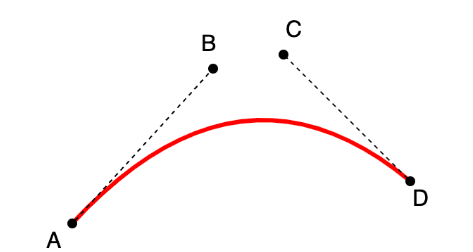

To implement bezier curves in PyCairo, we can follow the following steps:
1. Set the anchor A using `.move_to()`
2. Use the `.curve_to(xB, yB, xC, yC, xD, yD)` function to define the control points B and C and the final anchor D.
3. Set color and width of curve.
4. Stroke the path

The code below shows the implementation

In [108]:
# Clear surface
ctx.set_source_rgb(1, 1, 1)
ctx.paint()

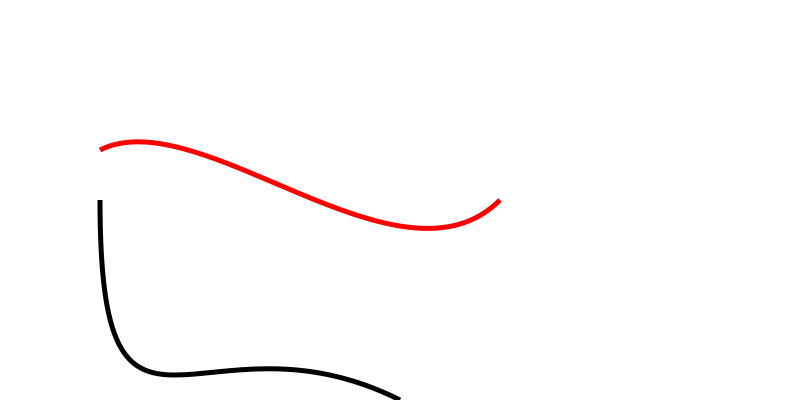

In [109]:
ctx.move_to(100,150) # set up first anchor point
ctx.curve_to(200,100,400,300,500,200) # set up control points then final anchor
ctx.set_source_rgb(1,0,0)
ctx.set_line_width(5)
ctx.stroke()

ctx.move_to(400,400) # set up first anchor point
ctx.curve_to(200,300,100,500,100,200) # set up control points then final anchor
ctx.set_source_rgb(0,0,0)
ctx.set_line_width(5)
ctx.stroke()

surface.write_to_png('Images/8.bezier_curve.png')
display(Image('Images/8.bezier_curve.png'))

## Line Styles

We can style the lines we use in our shapes/images to create varying decorative effects using attributes like:
- Line Caps
- Line Joins
- Line Dashing

### Line Caps

The line cap value affects how the ends of the lines are drawn. There are three options: 
- butt: squares off the ends exactly where the line ends. Is the default.
    - `.set_line_cap(cairo.LINE_CAP_BUTT)`
- square: extends the lines half the line width at the ends in a squared off manner
    - `.set_line_cap(cairo.LINE_CAP_SQUARE)`
- round: sets the end of the line to be rounded
    - `.set_line_cap(cairo.LINE_CAP_ROUND)`

In [110]:
# Clear surface
ctx.set_source_rgb(1, 1, 1)
ctx.paint()

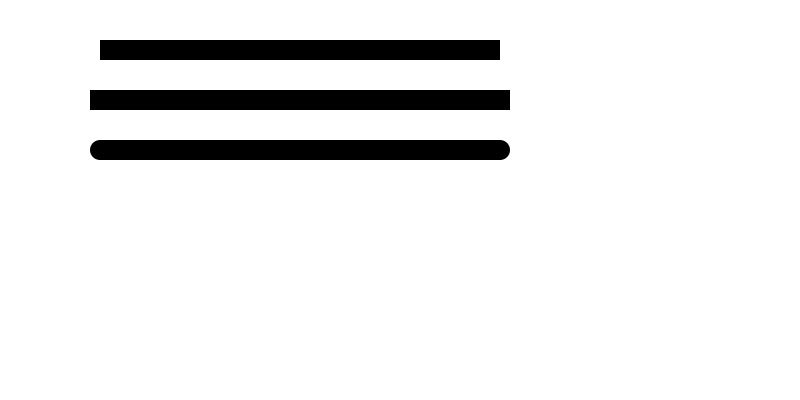

In [111]:
# Setting up the line
ctx.set_source_rgb(0,0,0)
ctx.set_line_width(20)

# Butt cap
ctx.move_to(100, 50)
ctx.line_to(500, 50)
ctx.set_line_cap(cairo.LINE_CAP_BUTT)
ctx.stroke()

# Square Cap
ctx.move_to(100, 100)
ctx.line_to(500, 100)
ctx.set_line_cap(cairo.LINE_CAP_SQUARE)
ctx.stroke()

# Round cap
ctx.move_to(100, 150)
ctx.line_to(500, 150)
ctx.set_line_cap(cairo.LINE_CAP_ROUND)
ctx.stroke()

surface.write_to_png('Images/9.line_caps.png')
display(Image('Images/9.line_caps.png'))

### Line Joins

We can control how lines join. There are three possible styles for joining lines:
- miter: default, creates a pointed end
    - `.set_line_join(cairo.LINE_JOIN_MITER)`
- round: rounds off our points
    - `.set_line_join(cairo.LINE_JOIN_ROUND)`
- bevel: removes the pointed end at the line joins with a straight cut.
    - `.set_line_join(cairo.LINE_JOIN_BEVEL)`

In [112]:
# Clear surface
ctx.set_source_rgb(1, 1, 1)
ctx.paint()

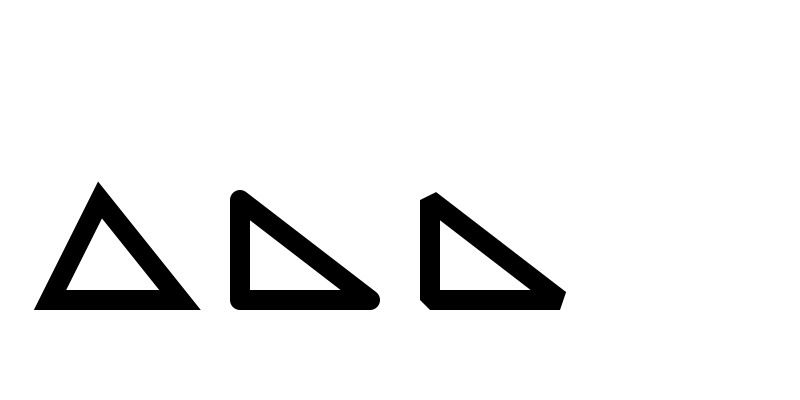

In [113]:
# Setting up the line
ctx.set_source_rgb(0,0,0)
ctx.set_line_width(20)

# Miter join >
ctx.move_to(100, 200)
ctx.line_to(180, 300)
ctx.line_to(50, 300)
ctx.close_path()
ctx.set_line_join(cairo.LINE_JOIN_MITER)
ctx.stroke()

# Round join )
ctx.move_to(240, 200)
ctx.line_to(370, 300)
ctx.line_to(240, 300)
ctx.close_path()
ctx.set_line_join(cairo.LINE_JOIN_ROUND)
ctx.stroke()

# Bevel join /
ctx.move_to(430, 200)
ctx.line_to(560, 300)
ctx.line_to(430, 300)
ctx.close_path()
ctx.set_line_join(cairo.LINE_JOIN_BEVEL)
ctx.stroke()


surface.write_to_png('Images/9.line_joins.png')
display(Image('Images/9.line_joins.png'))

### Dashed Lines

Dashed lines allow us to decorate and annotate.

We can define the dash pattern in the `.set_dash([on,off,...])` function

Some examples include:
- `set_dash(20)` : The list is repeated indefinitely to give a sequence 20, 20, 20, 20, and so on i.e., on for 20, off for 20.
- `set_dash([20,10])` : This gives a pattern of 20 on, 10 off, 20 on, 10 off, and so on.

In [114]:
surface = cairo.ImageSurface(cairo.FORMAT_RGB24, 600, 600)
ctx = cairo.Context(surface)
ctx.set_source_rgb(1, 1, 1)
ctx.paint()

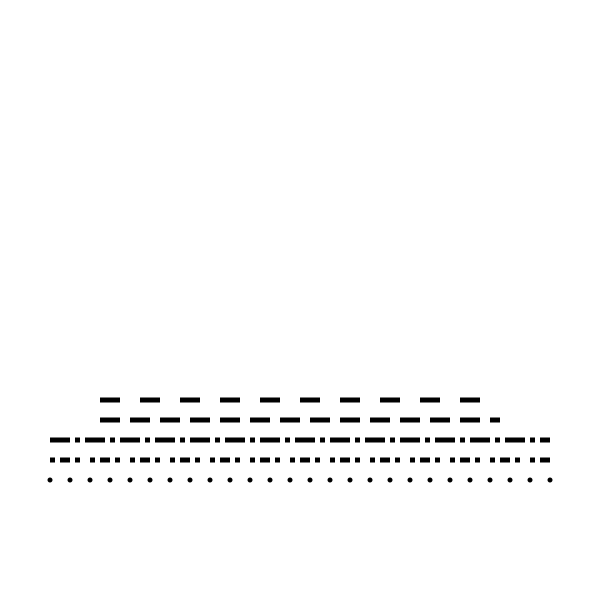

In [115]:

# Setting up the line
ctx.set_source_rgb(0,0,0)
ctx. set_line_width(5)

ctx.move_to(100, 400)
ctx.line_to(500, 400)
ctx.set_dash([20])
ctx.stroke()


ctx.move_to(100, 420)
ctx.line_to(500, 420)
ctx.set_dash([20,10])
ctx.stroke()


ctx.move_to(50, 440)
ctx.line_to(550, 440)
ctx.set_dash([20,5,5,5])
ctx.stroke()

ctx.move_to(50, 460)
ctx.line_to(550, 460)
ctx.set_dash([5,5,10])
ctx.stroke()

ctx.set_line_cap(cairo.LINE_CAP_ROUND)

ctx.move_to(50, 480)
ctx.line_to(550, 480)
ctx.set_dash([0,20])
ctx.stroke()

surface.write_to_png('Images/9.dashes.png')
display(Image('Images/9.dashes.png'))